# **Data Cleaning In Python** 🧼
After finishing EDA, the next phase is **Data Cleaning**, where you actually fix the problems discovered earlier.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#**Action(1): Handle Missing Values (Imputation)**
- Before imputing missing values, we must first understand why they are missing. Missingness may be caused by data-entry errors, system issues, or meaningful domain-specific reasons. Through EDA, we identify the pattern and cause of missingness. Only after understanding this can we choose an appropriate imputation strategy.

In [ ]:
df = pd.DataFrame({
    'EmployeeID': [101, 120, 111, 121, 157, 106, None],

    'Age': [25, None, 31, None, 40, 28, 30],

    'Gender': ['Male', None, 'Female', 'Male', 'Female', 'Male', 'Male'],

    'Department': ['IT', 'HR', 'IT', 'HR', 'IT', None, 'IT'],

    'Salary': [15000, 12000, None, 11000, None, 10000, 15000],

    # Bonus = Salary * 0.1, but some are missing
    'Bonus': [1500, None, None, 1100, None, 1000, 1500],

    # Notes = mostly null → to delete
    'Notes': [None, None, "Good performer", None, None, None, None]
})

df

,EmployeeID,Age,Gender,Department,Salary,Bonus,Notes
0,101.0,25.0,Male,IT,15000.0,1500.0,None
1,120.0,NaN,None,HR,12000.0,NaN,None
2,111.0,31.0,Female,IT,NaN,NaN,Good performer
3,121.0,NaN,Male,HR,11000.0,1100.0,None
4,157.0,40.0,Female,IT,NaN,NaN,None
5,106.0,28.0,Male,None,10000.0,1000.0,None
6,NaN,30.0,Male,IT,15000.0,1500.0,None


In [ ]:
df.isnull().sum().sum()

np.int64(16)

In [ ]:
df.isnull().mean()*100

,0
EmployeeID,14.285714
Age,28.571429
Gender,14.285714
Department,14.285714
Salary,28.571429
Bonus,42.857143
Notes,85.714286


**Case 0: Drop rows contains null values**

In [ ]:
df.dropna(subset=['EmployeeID'], inplace=True)

**Case 1: Imputing by mean**

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

**Case 2: Imputing by mode**

In [ ]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

**Case 3: Add a new category to represent the null values**

In [ ]:
df['Department'] = df['Department'].fillna('Unknown')

**Case 4: Imputing by mean/mode based on another categorical column**

In [ ]:
df['Salary'] = df['Salary'].fillna(df.groupby('Department')['Salary'].transform('mean'))

**Case 5: Calculate the value of null values based on another column**

In [ ]:
df['Bonus'] = df['Bonus'].fillna(df['Salary'] * 0.1)

**Case 6: Remove the entire column**

In [ ]:
df.drop(columns='Notes', inplace=True)

**Final result**

In [ ]:
df.isnull().sum()

,0
EmployeeID,0
Age,0
Gender,0
Department,0
Salary,0
Bonus,0


In [ ]:
df.head(10)

,EmployeeID,Age,Gender,Department,Salary,Bonus
0,101.0,25.0,Male,IT,15000.0,1500.0
1,120.0,31.0,Male,HR,12000.0,1200.0
2,111.0,31.0,Female,IT,15000.0,1500.0
3,121.0,31.0,Male,HR,11000.0,1100.0
4,157.0,40.0,Female,IT,15000.0,1500.0
5,106.0,28.0,Male,Unknown,10000.0,1000.0


**Another Example for handling missing Datausing different imputation methods**

In [ ]:
df_time = pd.DataFrame({
    'Date': pd.date_range(start='2025-11-10', periods=7, freq='D'),

    'Temperature': [30, None, 32, None, None, 28, 29],

    'Sales': [200, None, None, 250, None, None, 300],
})

df_time

,Date,Temperature,Sales
0,2025-11-10,30.0,200.0
1,2025-11-11,NaN,NaN
2,2025-11-12,32.0,NaN
3,2025-11-13,NaN,250.0
4,2025-11-14,NaN,NaN
5,2025-11-15,28.0,NaN
6,2025-11-16,29.0,300.0


In [ ]:
# Temperature: forward fill
df_time['Temperature'] = df_time['Temperature'].fillna(method='ffill')

# Sales: backfill
df_time['Sales'] = df_time['Sales'].fillna(method='bfill')

/tmp/ipython-input-2063426425.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_time['Temperature'] = df_time['Temperature'].fillna(method='ffill')
/tmp/ipython-input-2063426425.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_time['Sales'] = df_time['Sales'].fillna(method='bfill')


In [ ]:
df_time

,Date,Temperature,Sales
0,2025-11-10,30.0,200.0
1,2025-11-11,30.0,250.0
2,2025-11-12,32.0,250.0
3,2025-11-13,32.0,250.0
4,2025-11-14,32.0,300.0
5,2025-11-15,28.0,300.0
6,2025-11-16,29.0,300.0


#**Action(2): Handle Duplicated Values**


In [ ]:
df_dup = pd.DataFrame({
    'EmployeeID': [101, 102, 103, 101, 104, 102],
    'Name': ['Ali', 'Sara', 'Mona', 'Ali', 'Omar', 'Sara'],
    'Department': ['IT', 'HR', 'IT', 'IT', 'Finance', 'HR'],
    'Salary': [15000, 12000, 15000, 15000, 11000, 12000]
})

df_dup


,EmployeeID,Name,Department,Salary
0,101,Ali,IT,15000
1,102,Sara,HR,12000
2,103,Mona,IT,15000
3,101,Ali,IT,15000
4,104,Omar,Finance,11000
5,102,Sara,HR,12000


**Case 1: Drop all duplicate rows**

In [ ]:
df_no_dup = df_dup.drop_duplicates()

**Case 2: Drop duplicates based on a subset of columns**

In [ ]:
df_no_dup_subset = df_dup.drop_duplicates(subset=['EmployeeID', 'Name'])

In [ ]:
df.head()

,EmployeeID,Age,Gender,Department,Salary,Bonus
0,101.0,25.0,Male,IT,15000.0,1500.0
1,120.0,31.0,Male,HR,12000.0,1200.0
2,111.0,31.0,Female,IT,15000.0,1500.0
3,121.0,31.0,Male,HR,11000.0,1100.0
4,157.0,40.0,Female,IT,15000.0,1500.0


#**Action(3): Removing the Outliers**

In [ ]:
df_outlier = pd.DataFrame({
    'EmployeeID': [101, 102, 103, 104, 105, 106, 107],
    'Salary': [15000, 12000, 13000, 200000, 11000, 12500, 300000],
    'Age': [25, 30, 28, 27, 26, 29, 22]
})


In [ ]:
df_outlier

,EmployeeID,Salary,Age
0,101,15000,25
1,102,12000,30
2,103,13000,28
3,104,200000,27
4,105,11000,26
5,106,12500,29
6,107,300000,22


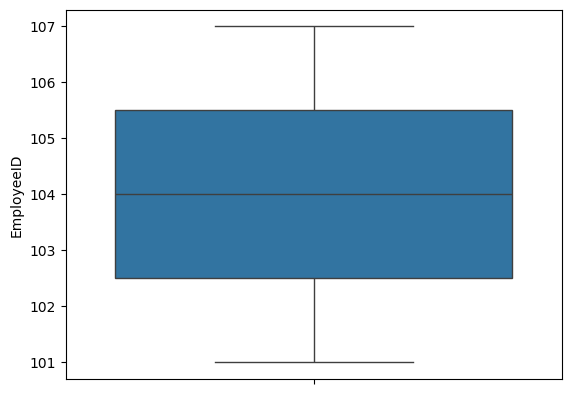

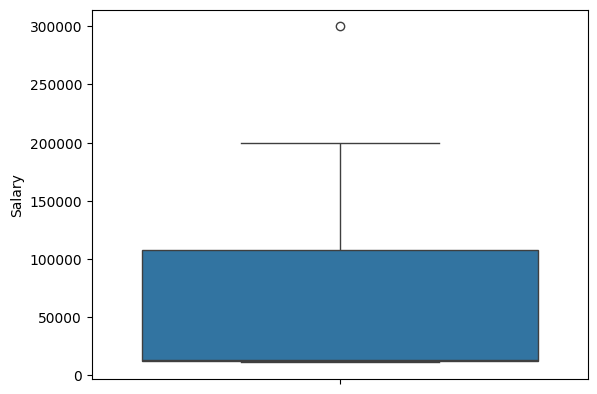

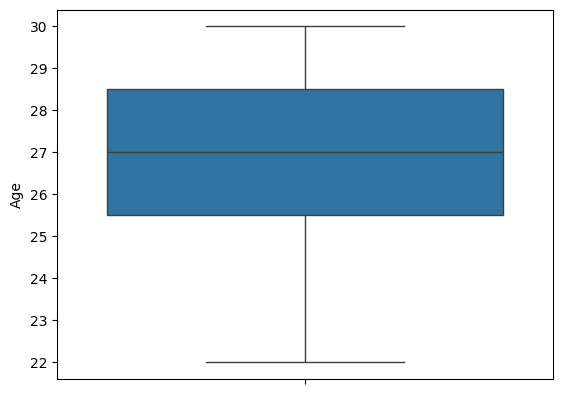

In [ ]:
for col in df_outlier.columns:
  sns.boxplot(df_outlier[col])
  plt.show()

In [ ]:
Q1 = df_outlier['Salary'].quantile(0.25)
Q3 = df_outlier['Salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = max(0, Q1 - 1.5 * IQR)                # K = 1.5 , can i change that to extend the fences or in sns.boxplot(..., whis=3)
upper_bound = Q3 + 1.5 * IQR

print(f"Salary lower bound: {lower_bound}, upper bound: {upper_bound}")


Salary lower bound: 0, upper bound: 250375.0


In [ ]:
df_outlier = df_outlier[(df_outlier['Salary'] >= lower_bound) & (df_outlier['Salary'] <= upper_bound)]

In [ ]:
df_outlier

,EmployeeID,Salary,Age
0,101,15000,25
1,102,12000,30
2,103,13000,28
3,104,200000,27
4,105,11000,26
5,106,12500,29
